I want to investigate the correlation between prices of different stocks, prices of a stock with different features and volatility with different features.

The most important column to search widh is probably the next future return, this should be our focus.

In [11]:
import yfinance as yf
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import tqdm
import datetime

tickers = ['NVDA', 'GOOGL', 'AAPL', 'GOOG', 'MSFT', 'AMZN', 'TSM', 'AVGO', 'META', 'TSLA', 'SMCI']

forex_tickers = [
    "EURUSD=X",
    "GBPUSD=X",
    "USDJPY=X",
    "USDCHF=X",
    "AUDUSD=X",
    "USDCAD=X",
    "NZDUSD=X",
    "EURGBP=X",
    "EURJPY=X",
    "GBPJPY=X",
    "EURCHF=X"
]

# for log and output save
now = datetime.datetime.now()
date = now.strftime("%Y-%m-%d %H:%M:%S")

[*********************100%***********************]  1 of 1 completed


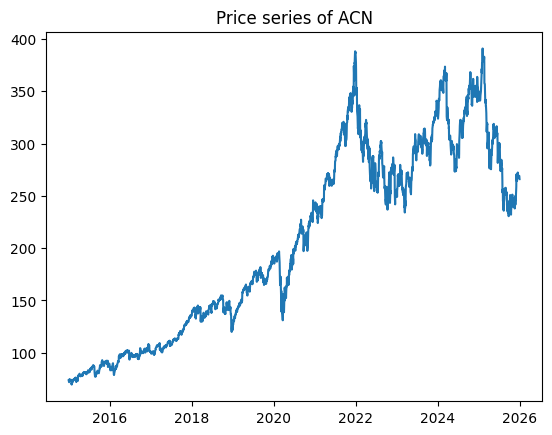

Price,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,73.628235,74.664202,73.288441,74.316118,2021300
2015-01-05,72.385048,73.197248,72.252447,72.965193,3000000
2015-01-06,71.862923,72.741420,71.282784,72.517654,2867000
2015-01-07,73.371307,73.553639,72.235892,72.235892,2865500
2015-01-08,74.490135,74.713908,73.628210,73.760817,2802900


In [2]:
def load_stock(start_date, stock='NVDA'):
    df = yf.download(stock, start=start_date, end='2026-01-01', interval='1d')

    if isinstance(df.columns, pd.MultiIndex):
        lvl0 = df.columns.get_level_values(0)
        lvl1 = df.columns.get_level_values(1)

        if 'Close' in lvl0:
            df.columns = lvl0
        elif 'Close' in lvl1:
            df.columns = lvl1

    df = df.loc[:, ~df.columns.duplicated()].copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    df = df.dropna(subset=['Close']).copy()
    return df

# here i will import the data for creating the time series
stock = 'ACN'
data = load_stock(start_date='2015-01-01', stock=stock)

plt.plot(data['Close'])
plt.title(f'Price series of {stock}')
plt.show()

data.head()

define features

In [3]:
nxxs, nxs, ns, nm, nb = 3,5,10,20,50

data['ret_1'] = data['Close'].pct_change(1) # (data['Close]-data['Close].shift(1))/data['Close].shift(1) -1
data['ret_5'] = data['Close'].pct_change(5)
data['ret_10'] = data['Close'].pct_change(10)
 
data[f'MA{ns}'] = data['Close'].rolling(ns).mean()
data[f'MA{nm}'] = data['Close'].rolling(nm).mean()
data[f'MA{nb}'] = data['Close'].rolling(nb).mean()

# better to calculate the distance (NORMALIZED) from the MA
data[f'MA{ns}dis'] = (data['Close']/data[f'MA{ns}'])-1
data[f'MA{nm}dis'] = (data['Close']/data[f'MA{nm}'])-1
data[f'MA{nb}dis'] = (data['Close']/data[f'MA{nb}'])-1

# exponential moving avg
def multiplier(n):
    return 2 / (n + 1)

def ema(n):
    col = f'EMA{n}'
    alpha = multiplier(n)

    data[col] = np.nan
    data.loc[data.index[0], col] = data['Close'].iloc[0]

    for i in range(1, len(data)):
        data.loc[data.index[i], col] = (
            alpha * data['Close'].iloc[i]
            + (1 - alpha) * data.loc[data.index[i - 1], col]
        )

ema(ns)
ema(nm)
ema(nb)

# ema distances
data[f'EMA{ns}dis'] = data['Close']/data[f'EMA{ns}'] - 1
data[f'EMA{nm}dis'] = data['Close']/data[f'EMA{nm}'] - 1
data[f'EMA{nb}dis'] = data['Close']/data[f'EMA{nb}'] - 1

# z-score
data[f'z{nxxs}'] = (data['Close']-data['Close'].rolling(nxxs).mean())/data['Close'].rolling(nxxs).std()
data[f'z{nxs}'] = (data['Close']-data['Close'].rolling(nxs).mean())/data['Close'].rolling(nxs).std()
data[f'z{ns}'] = (data['Close']-data['Close'].rolling(ns).mean())/data['Close'].rolling(ns).std()

# volatility
data[f'vol{nxs}'] = data['Close'].rolling(nxs).std()
data[f'vol{ns}'] = data['Close'].rolling(ns).std()
data[f'vol{nm}'] = data['Close'].rolling(nm).std()

# bollinger bands
# 2std aroud the moving avg, better to calculate the distance from the boundaries
data[f'bb_upper_{nm}_dis'] = data['Close']/(data[f'MA{nm}'] + 2*data[f'vol{nm}']) - 1
data[f'bb_lower_{nm}_dis'] = data['Close']/(data[f'MA{nm}'] - 2*data[f'vol{nm}']) - 1

# momentum (no leakage)
data[f'momentum{ns}'] = data['Close'] - data['Close'].shift(ns)
data[f'momentum{nm}'] = data['Close'] - data['Close'].shift(nm)



define the correlation matrix

In [4]:
features = [

    # returns (core signal)
    'ret_1',
    'ret_5',
    'ret_10',

    # moving average distances (trend / mean reversion)
    f'MA{ns}dis',
    f'MA{nm}dis',
    f'MA{nb}dis',

    # EMA distances (better than raw EMA)
    f'EMA{ns}dis',
    f'EMA{nm}dis',
    f'EMA{nb}dis',

    # z-score (mean reversion)
    f'z{nxxs}',
    f'z{nxs}',
    f'z{ns}',

    # volatility (regime)
    f'vol{nxs}',
    f'vol{ns}',
    f'vol{nm}',

    # bollinger position
    f'bb_upper_{nm}_dis',
    f'bb_lower_{nm}_dis',

    # momentum
    f'momentum{ns}',
    f'momentum{nm}',
]

In [5]:
# print the correlation of each feature with the return of the successive day
# <0.005 noise
# 0.005<corr<0.02 little
# 0.02<corr<0.05 usable
# >0.05 strong

data.columns = data.columns.get_level_values(-1)

data['ret_future_1'] = data['Close'].pct_change(1).shift(-1)

final_data = data[features + ['ret_future_1']].dropna()

corr = final_data.corr()['ret_future_1']
print(corr.sort_values(ascending=False)[10:])

Price
bb_lower_20_dis   -0.028315
MA20dis           -0.028875
MA50dis           -0.033520
z5                -0.034405
EMA20dis          -0.037716
EMA50dis          -0.038295
MA10dis           -0.041511
EMA10dis          -0.046023
z3                -0.048134
ret_1             -0.094906
Name: ret_future_1, dtype: float64


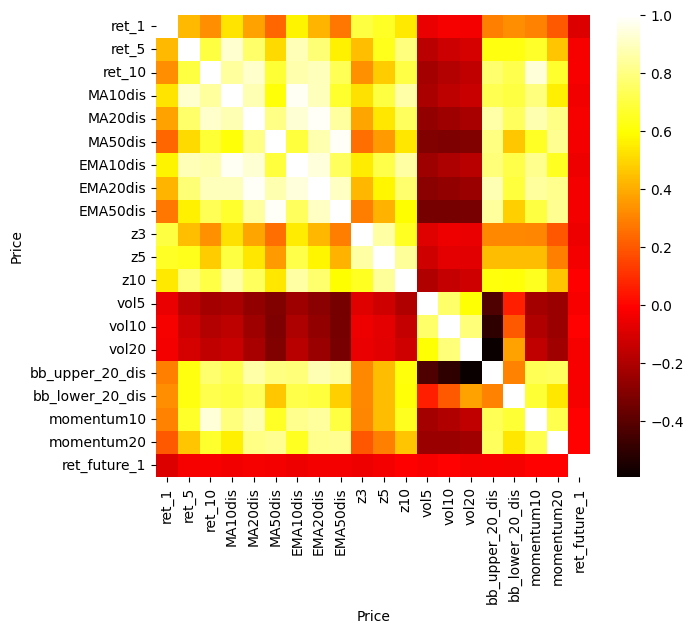

In [15]:
# plot correlation matrix of COLUMNS
plt.figure(figsize=(7,6))
col_map = 'hot'
# col_map = 'rocket'
# col_map = 'autumn'
sns.heatmap(final_data.corr(), cmap=col_map)
plt.show()